# gensort - Experiment 5: Imbalance Factor Impact


In [2]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp5_output'

# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [3]:
def parse_log_file_with_io(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            result['m4_read_mb'] = float(io_avg_match.group(9)) if io_avg_match.group(9) else 0.0
            result['m4_write_mb'] = float(io_avg_match.group(10)) if io_avg_match.group(10) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'] +
                                     result['m4_read_mb'] + result['m4_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file_with_io(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 51 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [4]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

In [5]:
# Load Exp5 data (Imbalance Factor Impact)
print("="*100)
print("EXP5: IMBALANCE FACTOR IMPACT (2GB RAM, Varying Imbalance)")
print("="*100)
df_exp5 = df_all[df_all['experiment'] == 'Exp5'].sort_values(['threads', 'partition_imbalance'])
display_cols = ['imbalance_factor', 'partition_imbalance', 'threads', 'memory_gb', 'total_time', 'rungen_time',
                'merge_time', 'throughput']

# Group by thread count and print separately
for thread_count in sorted(df_exp5['threads'].unique()):
    df_thread = df_exp5[df_exp5['threads'] == thread_count].sort_values('partition_imbalance')
    print(f"\n--- {thread_count} Threads ---")
    print(df_thread[display_cols].to_string(index=False))

    if not df_thread.empty and len(df_thread) > 1:
        best = df_thread.iloc[0]
        worst = df_thread.iloc[-1]
        print(f"\nBest (balanced): Target {best['imbalance_factor']:.1f}, Actual {best['partition_imbalance']:.2f} @ {best['total_time']:.1f}s")
        print(f"Worst (skewed): Target {worst['imbalance_factor']:.1f}, Actual {worst['partition_imbalance']:.2f} @ {worst['total_time']:.1f}s")
        degradation = (worst['total_time'] / best['total_time'] - 1) * 100
        print(f"Performance degradation: {degradation:.1f}%")

EXP5: IMBALANCE FACTOR IMPACT (2GB RAM, Varying Imbalance)

--- 4 Threads ---
 imbalance_factor  partition_imbalance  threads  memory_gb  total_time  rungen_time  merge_time  throughput
              1.0                 1.01        4          2     2438.66      1591.01      847.64        0.88
              1.5                 1.49        4          2     2584.64      1530.28     1054.36        0.83
              2.0                 2.00        4          2     2904.64      1584.78     1319.86        0.74
              3.0                 3.01        4          2     3328.63      1604.28     1724.35        0.65
              4.0                 4.00        4          2     4020.16      1834.01     2186.15        0.53

Best (balanced): Target 1.0, Actual 1.01 @ 2438.7s
Worst (skewed): Target 4.0, Actual 4.00 @ 4020.2s
Performance degradation: 64.9%

--- 24 Threads ---
 imbalance_factor  partition_imbalance  threads  memory_gb  total_time  rungen_time  merge_time  throughput
             

In [6]:
colors = {
    'total': '#1f77b4',
    'rungen': '#2ca02c', 
    'merge': '#d62728',
    'exp2': '#ff7f0e',
    'exp3': '#9467bd',
    'exp4': '#8c564b'
}

### Plot 5: Exp5 - Imbalance Factor Impact

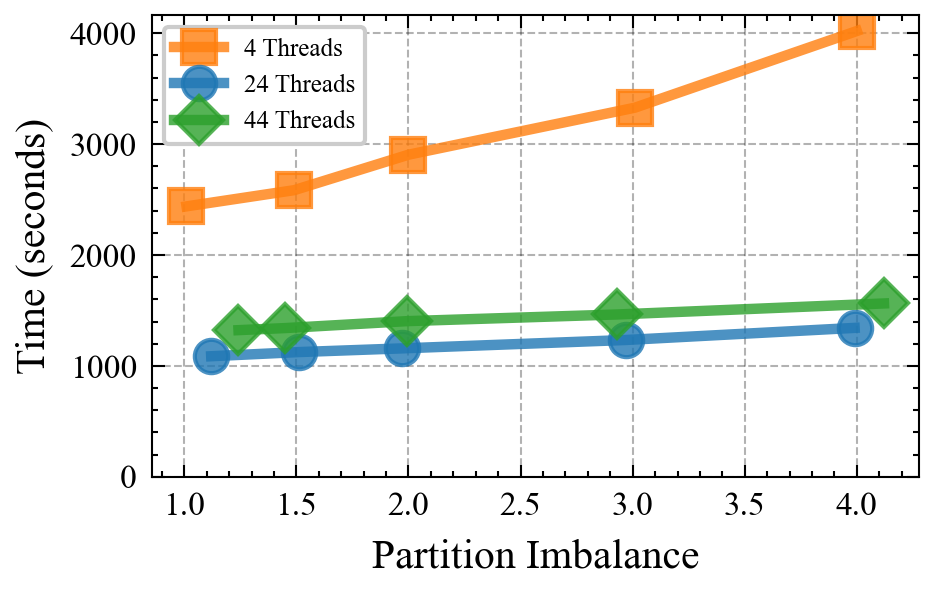

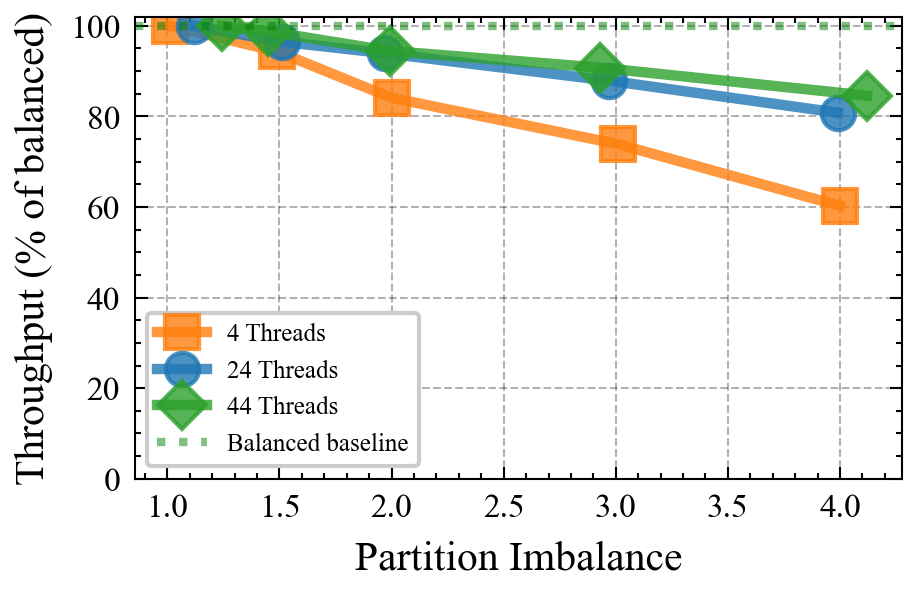


INSIGHTS BY THREAD COUNT (Using Actual Measured Imbalance)

4 Threads: Actual imbalance 4.00x (target 4.0x) causes 64.9% degradation vs balanced

24 Threads: Actual imbalance 3.99x (target 4.0x) causes 23.5% degradation vs balanced

44 Threads: Actual imbalance 4.12x (target 4.0x) causes 18.2% degradation vs balanced


In [9]:
# Figure 1: Time vs Actual Imbalance
fig1, ax1 = plt.subplots()

# Define colors and markers for different thread counts
thread_styles = {
    4: {'color': '#ff7f0e', 'marker': 's', 'label': '4 Threads'},
    24: {'color': '#1f77b4', 'marker': 'o', 'label': '24 Threads'},
    44: {'color': '#2ca02c', 'marker': 'D', 'label': '44 Threads'}
}

# Plot 5a: Time vs ACTUAL imbalance for each thread count
for thread_count in sorted(df_exp5['threads'].unique()):
    df_thread = df_exp5[df_exp5['threads'] == thread_count].sort_values('partition_imbalance')
    style = thread_styles.get(thread_count, {'color': 'gray', 'marker': 'x', 'label': f'{thread_count} Threads'})
    
    ax1.plot(df_thread['partition_imbalance'], df_thread['total_time'], 
             marker=style['marker'], linestyle='-', lw=2.5, markersize=8, 
             color=style['color'], label=style['label'], alpha=0.8)

ax1.set_xlabel('Partition Imbalance')
ax1.set_ylabel('Time (seconds)')
# ax1.set_title('Exp5: Total Time vs Actual Imbalance (2GB RAM)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='best')
ax1.set_ylim(bottom=0)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp5_time_vs_imbalance.png'), dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Throughput Degradation
fig2, ax2 = plt.subplots()

# Plot 5b: Throughput degradation for each thread count
for thread_count in sorted(df_exp5['threads'].unique()):
    df_thread = df_exp5[df_exp5['threads'] == thread_count].sort_values('partition_imbalance')
    style = thread_styles.get(thread_count, {'color': 'gray', 'marker': 'x', 'label': f'{thread_count} Threads'})
    
    # Calculate throughput percentage relative to balanced (lowest imbalance) for this thread count
    if len(df_thread) > 0:
        baseline_throughput = df_thread.iloc[0]['throughput']
        df_thread = df_thread.copy()
        df_thread['throughput_pct'] = (df_thread['throughput'] / baseline_throughput) * 100
        
        ax2.plot(df_thread['partition_imbalance'], df_thread['throughput_pct'], 
                 marker=style['marker'], linestyle='-', lw=2.5, markersize=8,
                 color=style['color'], label=style['label'], alpha=0.8)

ax2.axhline(y=100, color='green', linestyle=':', lw=2, alpha=0.5, label='Balanced baseline')
ax2.set_xlabel('Partition Imbalance')
ax2.set_ylabel('Throughput (% of balanced)')
# ax2.set_title('Performance Degradation with Skew', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(loc='best')
ax2.set_ylim(bottom=0)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp5_throughput_degradation.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print insights for each thread count
print("\n" + "="*80)
print("INSIGHTS BY THREAD COUNT (Using Actual Measured Imbalance)")
print("="*80)
for thread_count in sorted(df_exp5['threads'].unique()):
    df_thread = df_exp5[df_exp5['threads'] == thread_count].sort_values('partition_imbalance')
    if len(df_thread) > 1:
        best = df_thread.iloc[0]
        worst = df_thread.iloc[-1]
        degradation = (worst['total_time'] / best['total_time'] - 1) * 100
        print(f"\n{thread_count} Threads: Actual imbalance {worst['partition_imbalance']:.2f}x (target {worst['imbalance_factor']:.1f}x) causes {degradation:.1f}% degradation vs balanced")

## 4. Summary Dashboard